In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# Loading the dataset
df = pd.read_csv('car_price_prediction_.csv')

# Displaying first 5 rows of dataset
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [4]:
# shows us the data type of each column and if any values are missing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [5]:
# Generate summary statistics for numerical columns
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [6]:
# Checking for missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64


In [7]:
# Checking the unique values in categorical columns
print("Unique Brands:", df['Brand'].unique())
print("\nUnique Fuel Types:", df['Fuel Type'].unique())
print("\nUnique Transmissions:", df['Transmission'].unique())
print("\nUnique Conditions:", df['Condition'].unique())

Unique Brands: ['Tesla' 'BMW' 'Audi' 'Ford' 'Honda' 'Mercedes' 'Toyota']

Unique Fuel Types: ['Petrol' 'Electric' 'Diesel' 'Hybrid']

Unique Transmissions: ['Manual' 'Automatic']

Unique Conditions: ['New' 'Used' 'Like New']


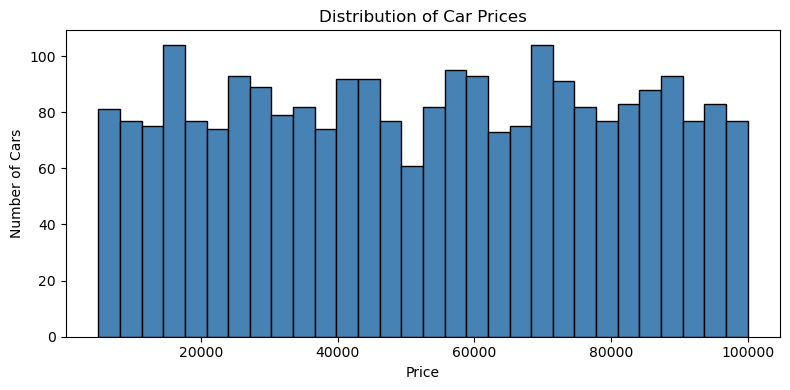

In [8]:
# Plotting the distribution of car prices
plt.figure(figsize=(8, 4))
plt.hist(df['Price'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show()

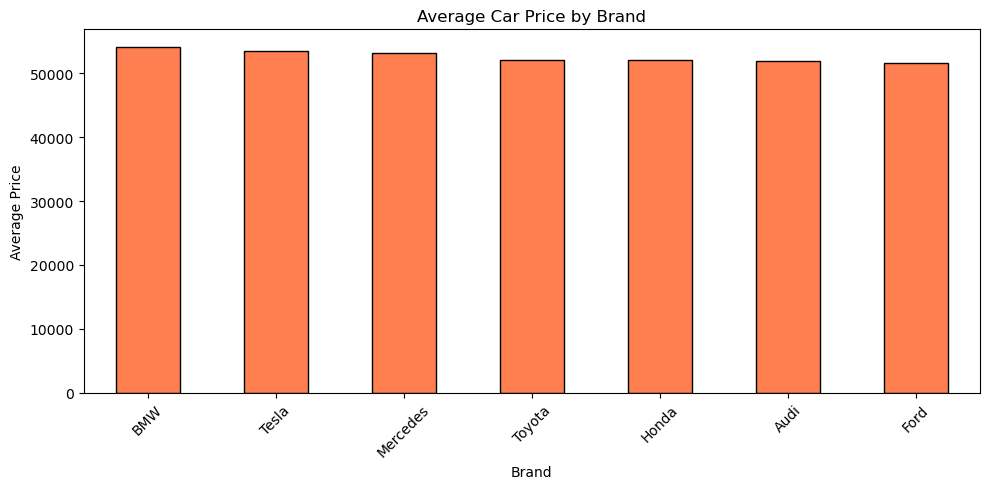

In [9]:
# Plotting the average car price for each brand
plt.figure(figsize=(10, 5))
brand_avg = df.groupby('Brand')['Price'].mean().sort_values(ascending=False)
brand_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Car Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

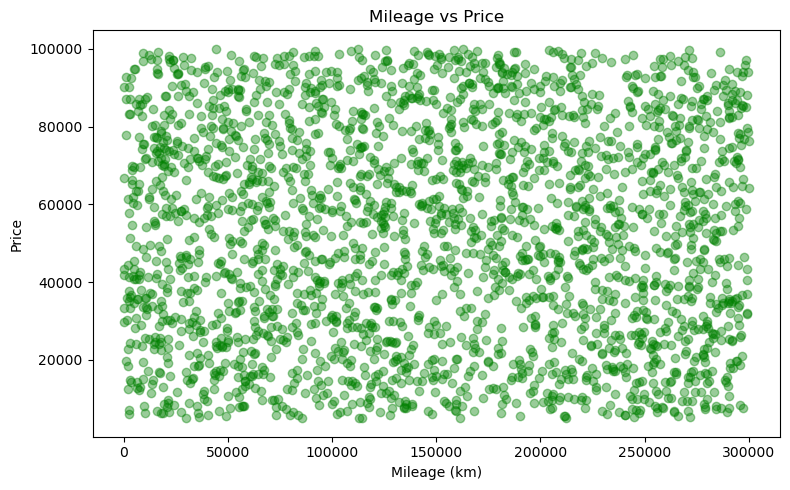

In [10]:
# Scatter plot to show the relationship between Mileage and Price
plt.figure(figsize=(8, 5))
plt.scatter(df['Mileage'], df['Price'], alpha=0.4, color='green')
plt.title('Mileage vs Price')
plt.xlabel('Mileage (km)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

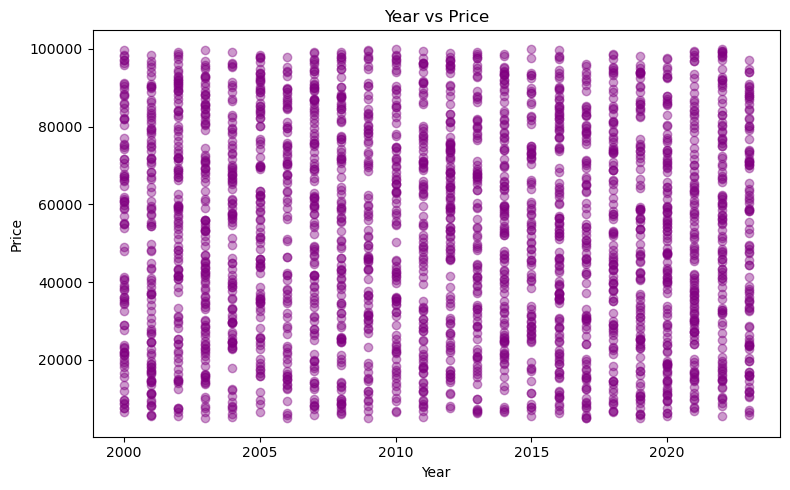

In [11]:
# Scatter plot to show the relationship between Year and Price
plt.figure(figsize=(8, 5))
plt.scatter(df['Year'], df['Price'], alpha=0.4, color='purple')
plt.title('Year vs Price')
plt.xlabel('Year')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

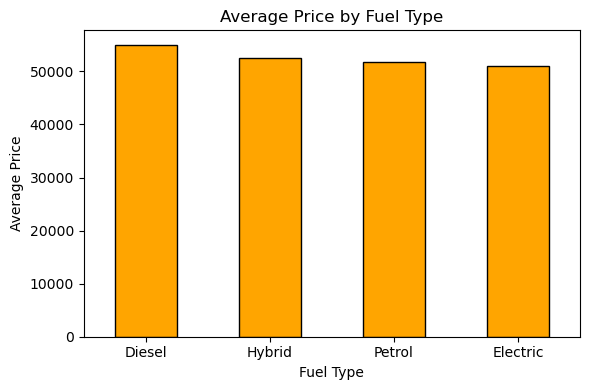

In [12]:
# Plotting the average car price for each fuel type
plt.figure(figsize=(6, 4))
df.groupby('Fuel Type')['Price'].mean().sort_values(ascending=False).plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

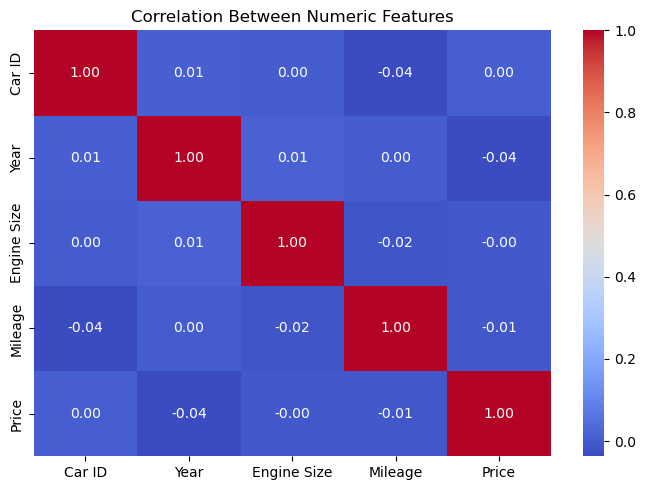


Note: Values close to 1 or -1 mean strong relationship. Close to 0 means weak relationship.


In [13]:
# Chart 6- Correlation heatmap - which numbers are related to each other?
plt.figure(figsize=(7, 5))
numeric_cols = df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

print("\nNote: Values close to 1 or -1 mean strong relationship. Close to 0 means weak relationship.")

In [14]:
# Dropping columns that are not useful for prediction
# 'Car ID' is just a number tag, 'Model' has too many unique values
df_clean = df.drop(columns=['Car ID', 'Model'])

print("Columns after dropping:")
print(df_clean.columns.tolist())

Columns after dropping:
['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Price']


In [15]:
# Converting text columns to numbers using Label Encoding
# LabelEncoder gives each unique text value a number
# Example: Petrol=2, Diesel=0, Electric=1

le = LabelEncoder()

text_columns = ['Brand', 'Fuel Type', 'Transmission', 'Condition']

for col in text_columns:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"{col} - encoded successfully")

print("\nFirst 3 rows after encoding:")
df_clean.head(3)

Brand - encoded successfully
Fuel Type - encoded successfully
Transmission - encoded successfully
Condition - encoded successfully

First 3 rows after encoding:


,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price
0,5,2016,2.3,3,1,114832,1,26613.92
1,1,2018,4.4,1,1,143190,2,14679.61
2,0,2013,4.5,1,1,181601,1,44402.61


In [16]:
# Double-check for any missing values
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
dtype: int64


In [17]:
# X are all columns EXCEPT Price
X = df_clean.drop(columns=['Price'])

# y are only the Price column
y = df_clean['Price']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features (X) shape: (2500, 7)
Target (y) shape: (2500,)

Feature columns: ['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition']


In [18]:
# Splitting data in 80% for training, 20% for testing
# Training data is data the model learns from
# Testing data is data we use to check how good the model is

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size:  {X_test.shape[0]} rows")

Training data size: 2000 rows
Testing data size:  500 rows


In [19]:
# Model 1 is Linear Regression 
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)   # train the model
lr_preds = lr_model.predict(X_test)  # make predictions on test data

print("Linear Regression trained!")

Linear Regression trained!


In [20]:
# Model 2 is Decision Tree 
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print("Decision Tree trained!")

Decision Tree trained!


In [21]:
# Model 3 is Random Forest 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest trained!")

Random Forest trained!


In [22]:
# Function to print all 3 metrics at once
def evaluate_model(name, y_test, predictions):
    mae  = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    print(f"--- {name} ---")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print()

evaluate_model("Linear Regression", y_test, lr_preds)
evaluate_model("Decision Tree",     y_test, dt_preds)
evaluate_model("Random Forest",     y_test, rf_preds)

--- Linear Regression ---
  MAE  : 23772.91
  RMSE : 27583.19
  R²   : -0.0043

--- Decision Tree ---
  MAE  : 29906.72
  RMSE : 37121.83
  R²   : -0.8191

--- Random Forest ---
  MAE  : 24488.75
  RMSE : 28550.91
  R²   : -0.0760



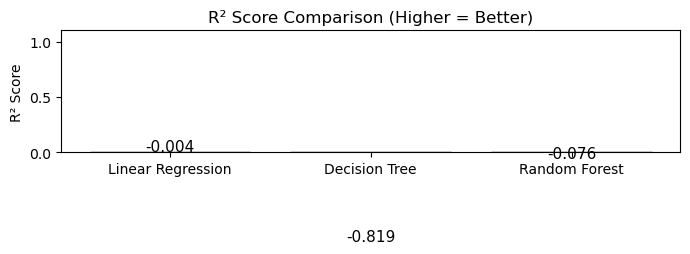

In [23]:
# Compare R² scores in a bar chart
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [
    r2_score(y_test, lr_preds),
    r2_score(y_test, dt_preds),
    r2_score(y_test, rf_preds)
]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, r2_scores, color=['steelblue', 'coral', 'green'], edgecolor='black')
plt.title('R² Score Comparison (Higher = Better)')
plt.ylabel('R² Score')
plt.ylim(0, 1.1)

# Show value on top of each bar
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

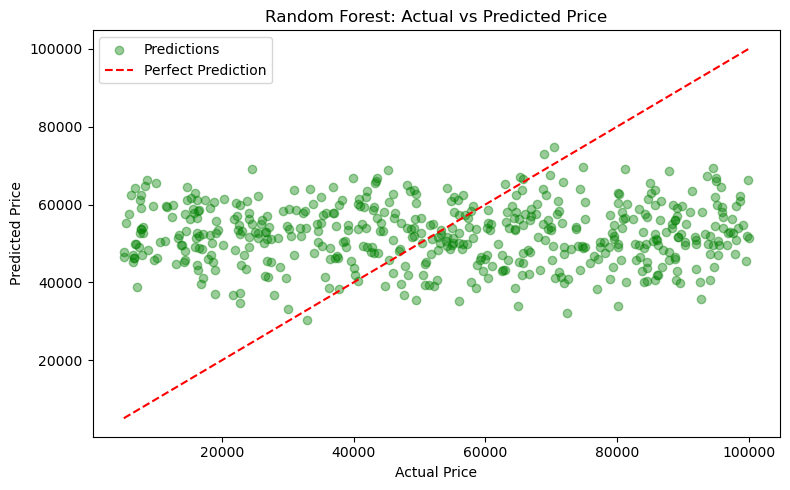

Dots closer to the red line = better predictions!


In [24]:
# Plotting Actual vs Predicted for Random Forest (usually best)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_preds, alpha=0.4, color='green', label='Predictions')

# Perfect prediction line
min_val = min(y_test.min(), rf_preds.min())
max_val = max(y_test.max(), rf_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.title('Random Forest: Actual vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()

print("Dots closer to the red line = better predictions!")

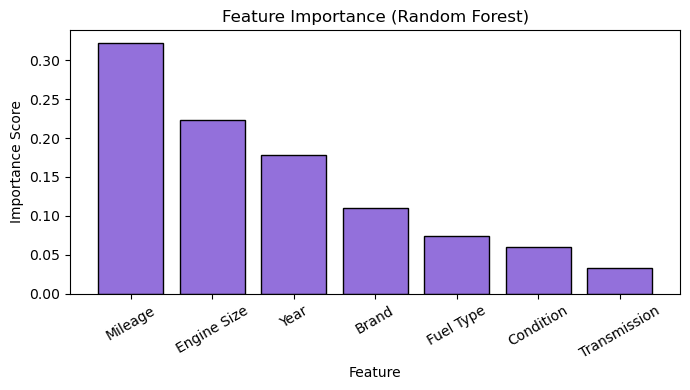

     Feature  Importance
     Mileage    0.322253
 Engine Size    0.222807
        Year    0.178270
       Brand    0.110209
   Fuel Type    0.074126
   Condition    0.059701
Transmission    0.032635


In [25]:
# Getting feature importances from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Sorting them from highest to lowest
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

# Plotting
plt.figure(figsize=(7, 4))
plt.bar(importance_df['Feature'], importance_df['Importance'], color='mediumpurple', edgecolor='black')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

In [26]:
# First let's see what number each category maps to
# checking for all encoded values to input correctly

for col in ['Brand', 'Fuel Type', 'Transmission', 'Condition']:
    le.fit(df[col])  # re-fit to get original mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col}: {mapping}")

Brand: {'Audi': 0, 'BMW': 1, 'Ford': 2, 'Honda': 3, 'Mercedes': 4, 'Tesla': 5, 'Toyota': 6}
Fuel Type: {'Diesel': 0, 'Electric': 1, 'Hybrid': 2, 'Petrol': 3}
Transmission: {'Automatic': 0, 'Manual': 1}
Condition: {'Like New': 0, 'New': 1, 'Used': 2}


In [27]:
# predicting the price for a sample car
# Replacing the values below with any car details you want to test

# Using encoded values from the mapping printed above
# Example car: Toyota, Year=2020, Engine=1.8, Petrol, Manual, 30000km, Used condition

sample_car = pd.DataFrame({
    'Brand':        [8],   # check the mapping above for correct number
    'Year':         [2020],
    'Engine Size':  [1.8],
    'Fuel Type':    [2],   # check the mapping above
    'Transmission': [1],   # check the mapping above
    'Mileage':      [30000],
    'Condition':    [1],   # check the mapping above
})

predicted_price = rf_model.predict(sample_car)
print(f"Predicted Price for the sample car: ${predicted_price[0]:,.2f}")

Predicted Price for the sample car: $55,000.44


In [28]:
#Simple Interface or dashboard for car price prediction 

def predict_price():

    # Encoding maps (lowercase so any typing style works)
    brand_map        = {'audi':0, 'bmw':1, 'ford':2, 'honda':3, 'mercedes':4, 'tesla':5, 'toyota':6}
    fuel_map         = {'diesel':0, 'electric':1, 'hybrid':2, 'petrol':3}
    transmission_map = {'automatic':0, 'manual':1}
    condition_map    = {'like new':0, 'new':1, 'used':2}

    # Take input from user
    brand        = input("Enter Brand (Toyota/BMW/Audi/Ford/Honda/Mercedes/Tesla): ")
    year         = input("Enter Year (e.g. 2018): ")
    engine       = input("Enter Engine Size (e.g. 1.8): ")
    fuel         = input("Enter Fuel Type (Petrol/Diesel/Electric/Hybrid): ")
    transmission = input("Enter Transmission (Manual/Automatic): ")
    mileage      = input("Enter Mileage in km (e.g. 45000): ")
    condition    = input("Enter Condition (New/Used/Like New): ")

    # Convert text to numbers
    b = brand_map[brand.strip().lower()]
    f = fuel_map[fuel.strip().lower()]
    t = transmission_map[transmission.strip().lower()]
    c = condition_map[condition.strip().lower()]

    # Predict price
    my_car = pd.DataFrame([[b, int(year), float(engine), f, t, int(mileage), c]],
             columns=['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition'])

    price = rf_model.predict(my_car)[0]

    # Show result
    print()
    print(f"Estimated Car Price: ${price:,.2f}")
    print()

predict_price()

Enter Brand (Toyota/BMW/Audi/Ford/Honda/Mercedes/Tesla):  bmw
Enter Year (e.g. 2018):  2018
Enter Engine Size (e.g. 1.8):  2.3
Enter Fuel Type (Petrol/Diesel/Electric/Hybrid):  manual
Enter Transmission (Manual/Automatic):  petrol
Enter Mileage in km (e.g. 45000):  45000
Enter Condition (New/Used/Like New):  new


KeyError: 'manual'